In [1]:
import common_functions

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dust_points_vars = "DATA/processed/3_dust_points_vars_2026-05-07.csv"
dust_df = pd.read_csv(dust_points_vars)

# Plot CDF by moisture

In [3]:
def plot_cdf(dust_df_sorted, column_name, selected_list, colors):

    fig, ax = plt.subplots(figsize=(15, 6))

    for i, category in enumerate(selected_list):
        subset = dust_df_sorted[dust_df_sorted[column_name] == category]
        ax.step(subset['moisture'], subset['cum_pct'], where='post', 
                label=selected_list[i],
                color=colors[i], 
                linewidth=3)

    ax.set_xlim(0, 0.35)
    ax.set_xlabel('Soil Moisture (0-10 cm) [m³/m³]', size=15)
    ax.set_ylabel('Cumulative Percentage (%)', size=15)
    ax.set_title('Dust events by moisture and category', size=18)
    ax.tick_params(axis='both', which='major', labelsize=15) 
    ax.legend(fontsize=15)

    plt.gca().invert_xaxis()
    plt.tight_layout()
    plt.show()
    return

In [4]:
def usage_info_for_cdf(dust_df):
    print("Getting usage names and choosing which to plot...")
    # selected_usages = [7, 15, 8, 16, 10]
    selected_usages = ["Tropical/Sub-tropical Shrubland", "Cropland", "Temp/Sub-polar Shrubland", "Barren Lands", "Temp/Sub-polar Grassland"]
    land_cover_dict, land_cover_colors, classes = common_functions.get_land_cover_features()
    
    dust_df["usage_name"] = dust_df["usage"].map(land_cover_dict)
    dust_df_filtered = dust_df[dust_df["usage_name"].isin(selected_usages)]
    colors = [
        "#7a554f", #Tropical/Sub-tropical Shrubland
        "#e7cd24", #Cropland
        "#a28073", #Temp/Sub-polar Shrubland
        "#F60707", #Barren Lands
        "#9db72b", #Temp/Sub-polar Grassland
    ]
    column_name = "usage_name"

    print("Building and plotting the usage cumulative distribution function...")
    #freq of dust = blowing per domain / domain count 
    dust_df_sorted = dust_df_filtered.sort_values(['usage_name', 'moisture'], ascending=False)
    dust_df_sorted['cum_pct'] = dust_df_sorted.groupby('usage_name').cumcount() + 1
    dust_df_sorted['cum_pct'] = dust_df_sorted['cum_pct'] / dust_df_sorted.groupby('usage_name')['cum_pct'].transform('max') * 100

    return dust_df_sorted, column_name, selected_usages, colors

Getting usage names and choosing which to plot...
Building and plotting the usage cumulative distribution function...


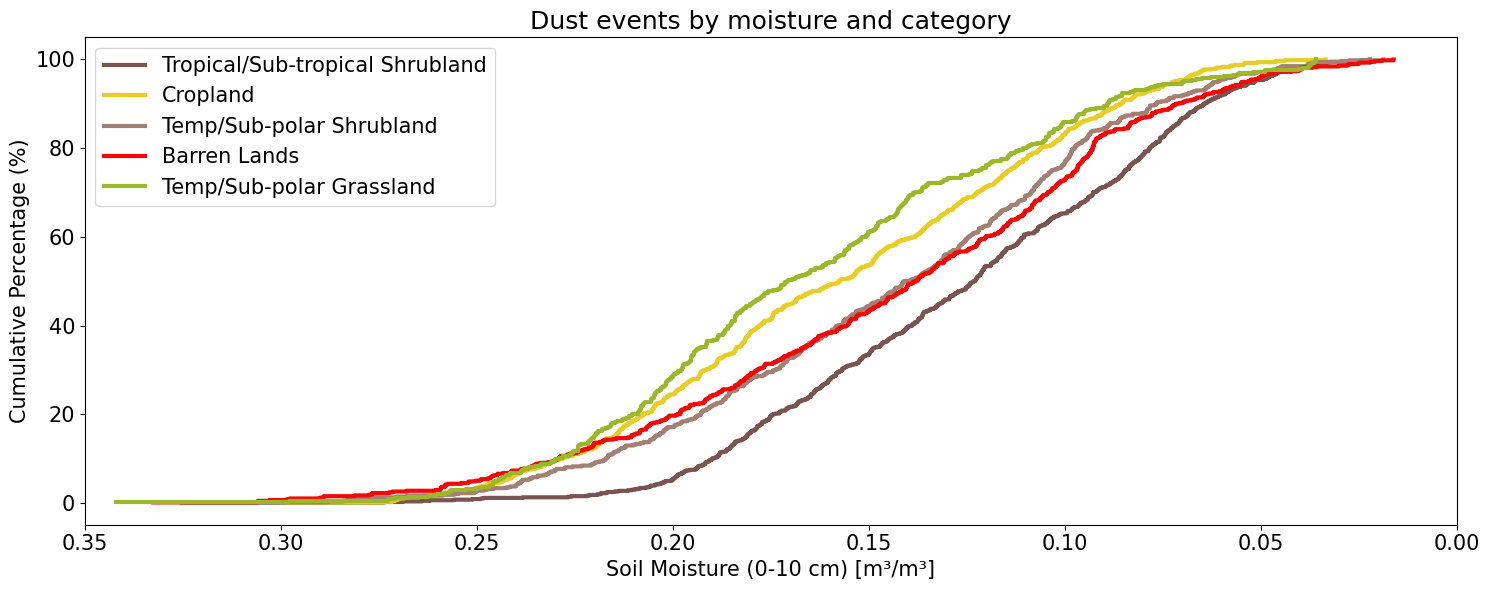

In [5]:
dust_df_sorted, column_name, selected_list, colors = usage_info_for_cdf(dust_df)
plot_cdf(dust_df_sorted, column_name, selected_list, colors)

In [6]:
def soil_order_info_for_cdf(dust_df):
    print("Getting soil order names and choosing which to plot...")
    soil_order_dict, category_colors = common_functions.get_soil_order_features()
    dust_df["soil_order_name"] = dust_df["soil_order"].map(soil_order_dict)
    selected_soil_orders = ['Aridisols', 'Entisols', 'Mollisols', 'Alfisols', 'Shifting Sands']
    dust_df_filtered = dust_df[dust_df["soil_order_name"].isin(selected_soil_orders)]

    colors = [
        "#f1af4c", #Aridisols
        "#dc5908", #Entisols
        "#046a2b", #Mollisols
        "#06dd0a", #Alfisols
        "#a8a6a4" #Shifting Sands
    ]
    column_name = "soil_order_name"
    
    print("Building and plotting the order cumulative distribution function...")
    #freq of dust = blowing per domain / domain count
    dust_df_sorted = dust_df_filtered.sort_values(['soil_order_name', 'moisture'], ascending=False)
    dust_df_sorted['cum_pct'] = dust_df_sorted.groupby('soil_order_name').cumcount() + 1
    dust_df_sorted['cum_pct'] = dust_df_sorted['cum_pct'] / dust_df_sorted.groupby('soil_order_name')['cum_pct'].transform('max') * 100

    return dust_df_sorted, column_name, selected_soil_orders, colors

Getting soil order names and choosing which to plot...
Building and plotting the order cumulative distribution function...


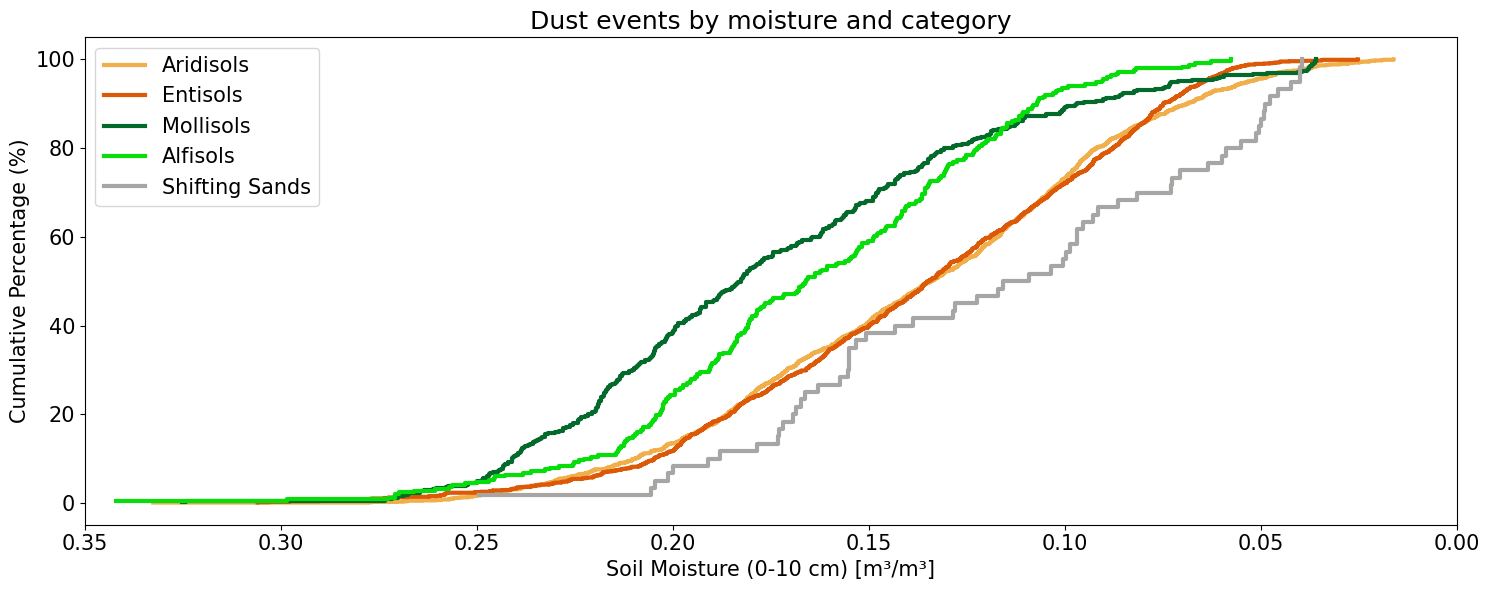

In [7]:
dust_df_sorted, column_name, selected_list, colors = soil_order_info_for_cdf(dust_df)
plot_cdf(dust_df_sorted, column_name, selected_list, colors)

In [8]:
def texture_info_for_cdf(dust_df):
    print("Getting texture names and choosing which to plot...")
    soil_cmap, texture_colors, texture_dict = common_functions.get_texture_map_features()
    dust_df["texture_name"] = dust_df["texture"].map(texture_dict)
    selected_texture_orders = ['Sand', 'Sandy Loam', 'Loam', 'Sandy Clay Loam', 'Silty Clay', 'Clay']
    dust_df_filtered = dust_df[dust_df["texture_name"].isin(selected_texture_orders)]

    colors = [
        "#EE6352",  # Sand
        "#d9c070",  # Sandy Loam
        "#a67c52",  # Loam
        "#16DB93",  # Sandy Clay Loam
        "#048BA8",  # Silty Clay
        "#4f1f18",  # Clay
    ]
    column_name = "texture_name"
    
    print("Building and plotting the order cumulative distribution function...")
    #freq of dust = blowing per domain / domain count
    dust_df_sorted = dust_df_filtered.sort_values(['texture_name', 'moisture'], ascending=False)
    dust_df_sorted['cum_pct'] = dust_df_sorted.groupby('texture_name').cumcount() + 1
    dust_df_sorted['cum_pct'] = dust_df_sorted['cum_pct'] / dust_df_sorted.groupby('texture_name')['cum_pct'].transform('max') * 100

    return dust_df_sorted, column_name, selected_texture_orders, colors


Getting texture names and choosing which to plot...
Building and plotting the order cumulative distribution function...


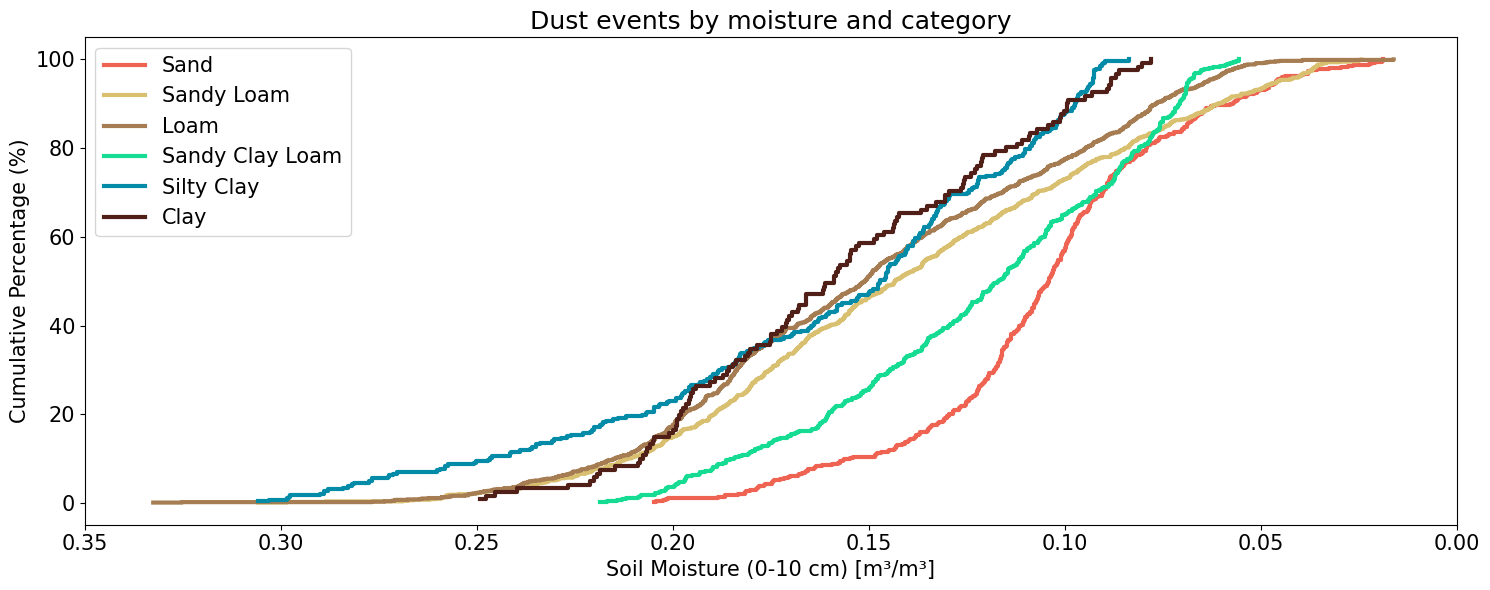

In [9]:
dust_df_sorted, column_name, selected_list, colors = texture_info_for_cdf(dust_df)
plot_cdf(dust_df_sorted, column_name, selected_list, colors)

# Plot CDF by wind speed

In [10]:
def plot_cdf(dust_df_sorted, column_name, selected_list, colors):

    fig, ax = plt.subplots(figsize=(15, 6))

    for i, category in enumerate(selected_list):
        subset = dust_df_sorted[dust_df_sorted[column_name] == category]
        ax.step(subset['wind_speed'], subset['cum_pct'], where='post', 
                label=selected_list[i],
                color=colors[i], 
                linewidth=3)

    ax.set_xlim(0, 20)
    ax.set_xlabel('Wind Speed (m/s)', size=15)
    ax.set_ylabel('Cumulative Percentage (%)', size=15)
    ax.set_title('Dust events by wind speed and category', size=18)
    ax.tick_params(axis='both', which='major', labelsize=15) 
    ax.legend(fontsize=15)

    plt.tight_layout()
    plt.show()
    return

In [11]:
def usage_info_for_cdf(dust_df):
    print("Getting usage names and choosing which to plot...")
    # selected_usages = [7, 15, 8, 16, 10]
    selected_usages = ["Tropical/Sub-tropical Shrubland", "Cropland", "Temp/Sub-polar Shrubland", "Barren Lands", "Temp/Sub-polar Grassland"]
    land_cover_dict, land_cover_colors, classes = common_functions.get_land_cover_features()
 
    dust_df["usage_name"] = dust_df["usage"].map(land_cover_dict)
    dust_df_filtered = dust_df[dust_df["usage_name"].isin(selected_usages)]
    colors = [
        "#7a554f", #Tropical/Sub-tropical Shrubland
        "#e7cd24", #Cropland
        "#a28073", #Temp/Sub-polar Shrubland
        "#F60707", #Barren Lands
        "#9db72b", #Temp/Sub-polar Grassland
    ]
    column_name = "usage_name"

    print("Building and plotting the usage cumulative distribution function...")
    #freq of dust = blowing per domain / domain count 
    dust_df_sorted = dust_df_filtered.sort_values(['usage_name', 'wind_speed'])
    dust_df_sorted['cum_pct'] = dust_df_sorted.groupby('usage_name').cumcount() + 1
    dust_df_sorted['cum_pct'] = dust_df_sorted['cum_pct'] / dust_df_sorted.groupby('usage_name')['cum_pct'].transform('max') * 100

    return dust_df_sorted, column_name, selected_usages, colors

Getting usage names and choosing which to plot...
Building and plotting the usage cumulative distribution function...


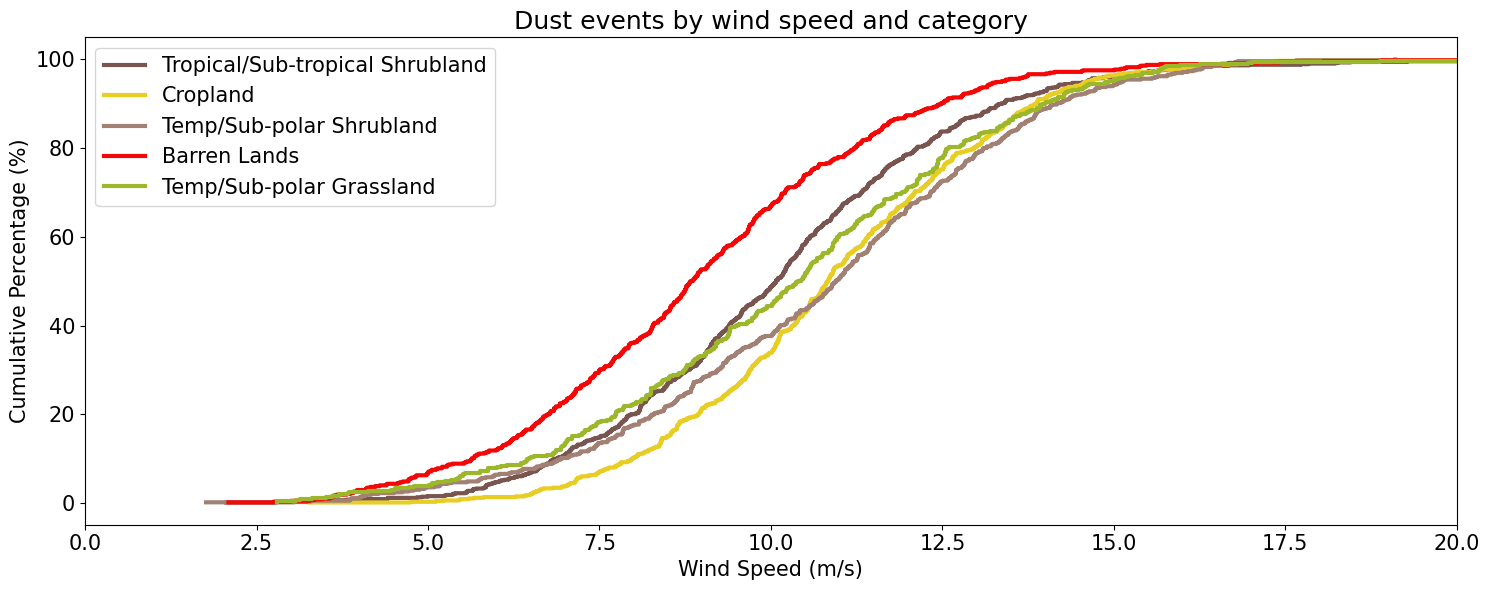

In [12]:
dust_df_sorted, column_name, selected_list, colors = usage_info_for_cdf(dust_df)
plot_cdf(dust_df_sorted, column_name, selected_list, colors)

In [13]:
def soil_order_info_for_cdf(dust_df):
    print("Getting soil order names and choosing which to plot...")
    soil_order_dict, category_colors = common_functions.get_soil_order_features()
    dust_df["soil_order_name"] = dust_df["soil_order"].map(soil_order_dict)
    selected_soil_orders = ['Aridisols', 'Entisols', 'Mollisols', 'Alfisols', 'Shifting Sands']
    dust_df_filtered = dust_df[dust_df["soil_order_name"].isin(selected_soil_orders)]

    colors = [
        "#f1af4c", #Aridisols
        "#dc5908", #Entisols
        "#046a2b", #Mollisols
        "#06dd0a", #Alfisols
        "#a8a6a4" #Shifting Sands
    ]
    column_name = "soil_order_name"
    
    print("Building and plotting the order cumulative distribution function...")
    #freq of dust = blowing per domain / domain count
    dust_df_sorted = dust_df_filtered.sort_values(['soil_order_name', 'wind_speed'])
    dust_df_sorted['cum_pct'] = dust_df_sorted.groupby('soil_order_name').cumcount() + 1
    dust_df_sorted['cum_pct'] = dust_df_sorted['cum_pct'] / dust_df_sorted.groupby('soil_order_name')['cum_pct'].transform('max') * 100

    return dust_df_sorted, column_name, selected_soil_orders, colors

Getting soil order names and choosing which to plot...
Building and plotting the order cumulative distribution function...


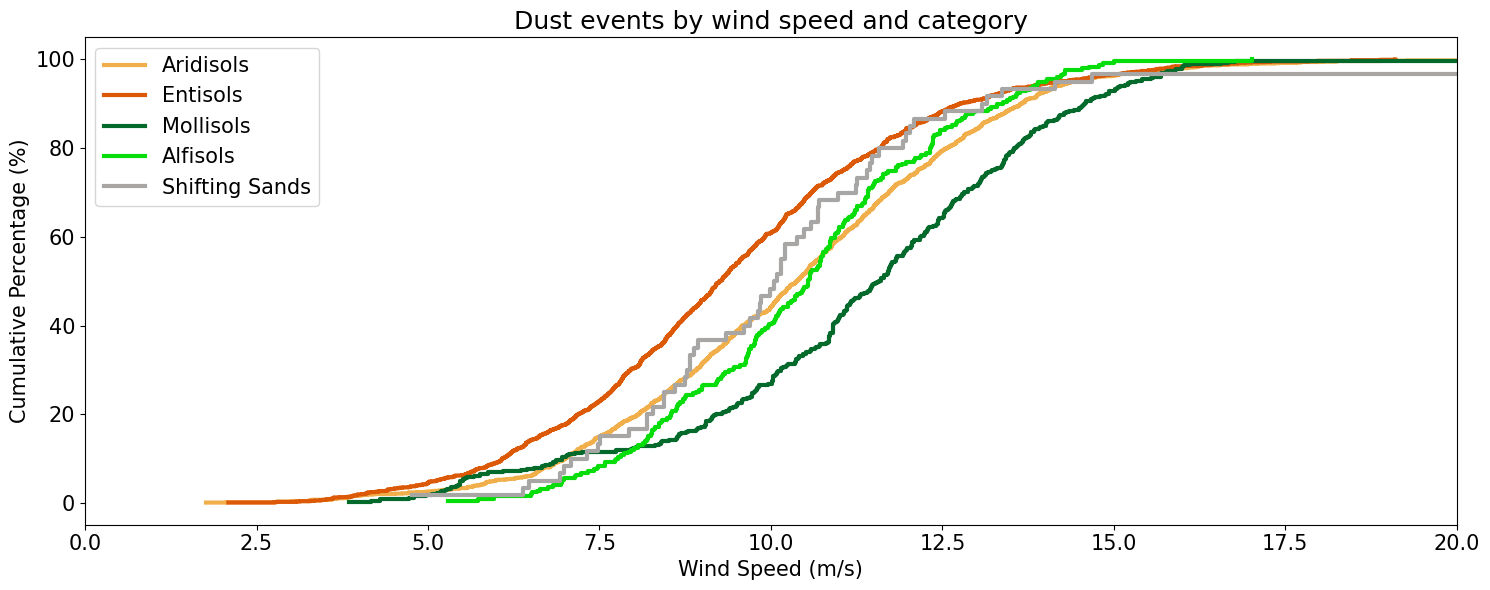

In [14]:
dust_df_sorted, column_name, selected_list, colors = soil_order_info_for_cdf(dust_df)
plot_cdf(dust_df_sorted, column_name, selected_list, colors)

In [15]:
def texture_info_for_cdf(dust_df):
    print("Getting texture names and choosing which to plot...")
    soil_cmap, texture_colors, texture_dict = common_functions.get_texture_map_features()
    selected_texture_orders = ['Sand', 'Sandy Loam', 'Loam', 'Sandy Clay Loam', 'Silty Clay', 'Clay']
    dust_df_filtered = dust_df[dust_df["texture_name"].isin(selected_texture_orders)]

    colors = [
        "#EE6352",  # Sand
        "#d9c070",  # Sandy Loam
        "#a67c52",  # Loam
        "#16DB93",  # Sandy Clay Loam
        "#048BA8",  # Silty Clay
        "#4f1f18",  # Clay
    ]
    column_name = "texture_name"
    
    print("Building and plotting the order cumulative distribution function...")
    #freq of dust = blowing per domain / domain count
    dust_df_sorted = dust_df_filtered.sort_values(['texture_name', 'wind_speed'])
    dust_df_sorted['cum_pct'] = dust_df_sorted.groupby('texture_name').cumcount() + 1
    dust_df_sorted['cum_pct'] = dust_df_sorted['cum_pct'] / dust_df_sorted.groupby('texture_name')['cum_pct'].transform('max') * 100

    return dust_df_sorted, column_name, selected_texture_orders, colors

Getting texture names and choosing which to plot...
Building and plotting the order cumulative distribution function...


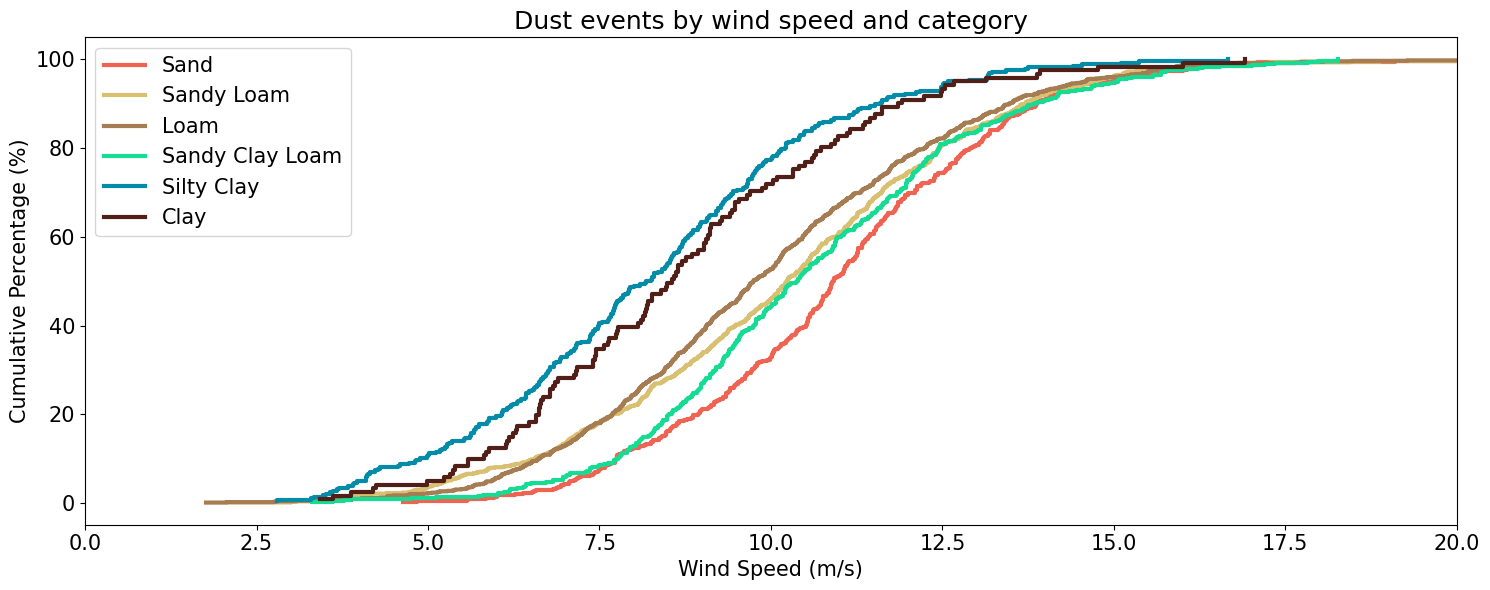

In [16]:
dust_df_sorted, column_name, selected_list, colors = texture_info_for_cdf(dust_df)
plot_cdf(dust_df_sorted, column_name, selected_list, colors)

# Plot CDF moisture by wind speed

In [17]:
def moisture_info_for_cdf(dust_df):
    print("Making moisture categories...")
    moisture_bins = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25]
    moisture_labels = ["0.00-0.05", "0.05-0.10", "0.10-0.15", "0.15-0.20", "0.20-0.25"]
    dust_df["moisture"] = pd.to_numeric(dust_df["moisture"], errors="coerce")
    dust_df["moisture_category"] = pd.cut(
        dust_df["moisture"],
        bins=moisture_bins,
        labels=moisture_labels,
        include_lowest=True
    )
    dust_df_filtered = dust_df.dropna(subset=["moisture_category"])

    colors = [
        "#8c510a",  # Extremely Dry – dark soil brown
        "#bf812d",  # Very Dry – warm earth
        "#dfc27d",  # Dry – tan soil
        "#80cdc1",  # Slightly Moist – muted teal
        "#35978f",  # Moist – strong teal
    ]
    column_name = "moisture_category"
    
    print("Building and plotting the order cumulative distribution function...")
    #freq of dust = blowing per domain / domain count
    dust_df_sorted = dust_df_filtered.sort_values(['moisture_category', 'wind_speed'])
    dust_df_sorted['cum_pct'] = dust_df_sorted.groupby('moisture_category', observed=False).cumcount() + 1
    dust_df_sorted['cum_pct'] = dust_df_sorted['cum_pct'] / dust_df_sorted.groupby('moisture_category', observed=False)['cum_pct'].transform('max') * 100
    return dust_df_sorted, column_name, moisture_labels, colors

Making moisture categories...
Building and plotting the order cumulative distribution function...


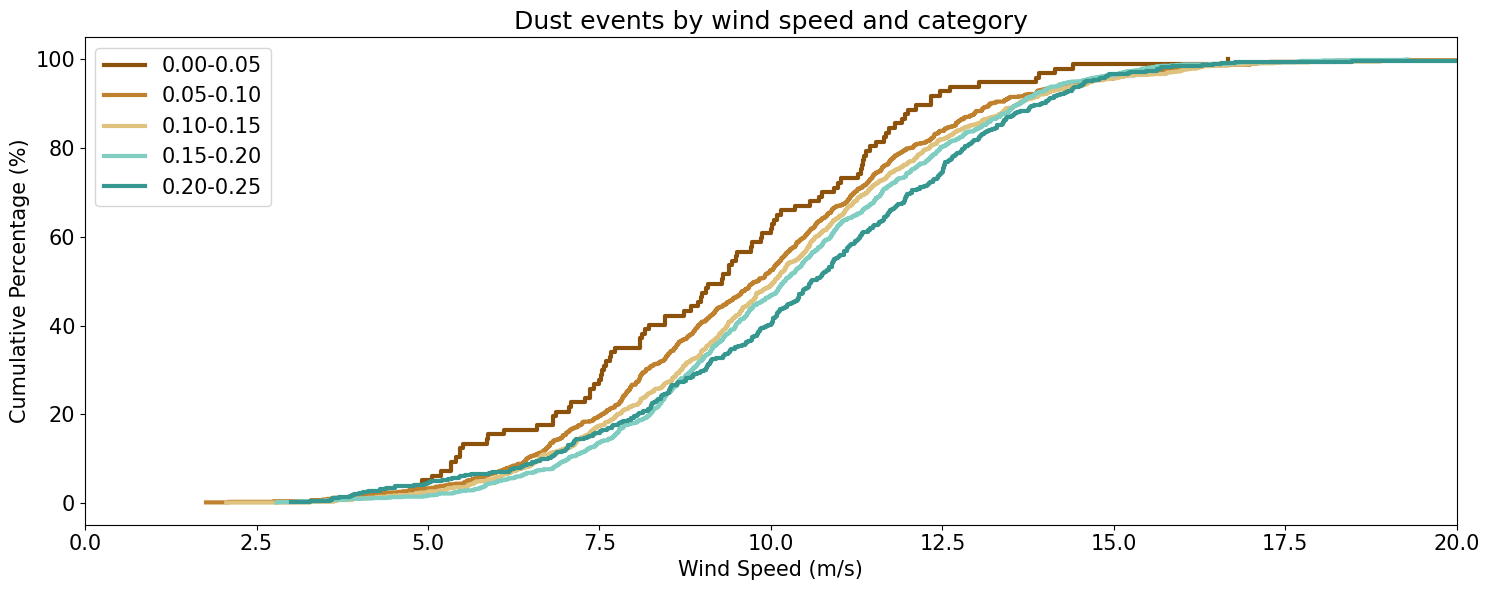

In [18]:
dust_df_sorted, column_name, selected_list, colors = moisture_info_for_cdf(dust_df)
plot_cdf(dust_df_sorted, column_name, selected_list, colors)